In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df=pd.read_csv('food.csv')

In [14]:
df.head()

,Name,Gender,City,Frequency,Item,Spends
0,Lily Pruitt,Male,Hyderabad,Weekly,Burger,11
1,Gatlin Martin,Male,Pune,Daily,Paneer,14
2,Mila Guevara,Female,Rajkot,Once,Chicken,23
3,Tommy Glover,Male,Indore,Monthly,Sandwich,56
4,Alessia Kirk,Male,Bangalore,Never,Burger,34


In [15]:
# Statistical summary of the 'Spends' column
print("Spending Statistics:\n", df['Spends'].describe())
# Checking the most popular food items
print("\nItem Counts:\n", df['Item'].value_counts())
# Checking the unique cities and genders in the data
print("\nUnique Cities:", df['City'].unique())

Spending Statistics:
 count    50.000000
mean     35.320000
std      25.323571
min       2.000000
25%      12.250000
50%      31.000000
75%      53.750000
max      98.000000
Name: Spends, dtype: float64

Item Counts:
 Item
Burger      11
Paneer      10
Pizza       10
Vada         7
Chicken      6
Sandwich     6
Name: count, dtype: int64

Unique Cities: ['Hyderabad' 'Pune' 'Rajkot' 'Indore' 'Bangalore' 'Mumbai' 'Kolkata'
 'Delhi' 'Chandigarh' 'Kanpur']


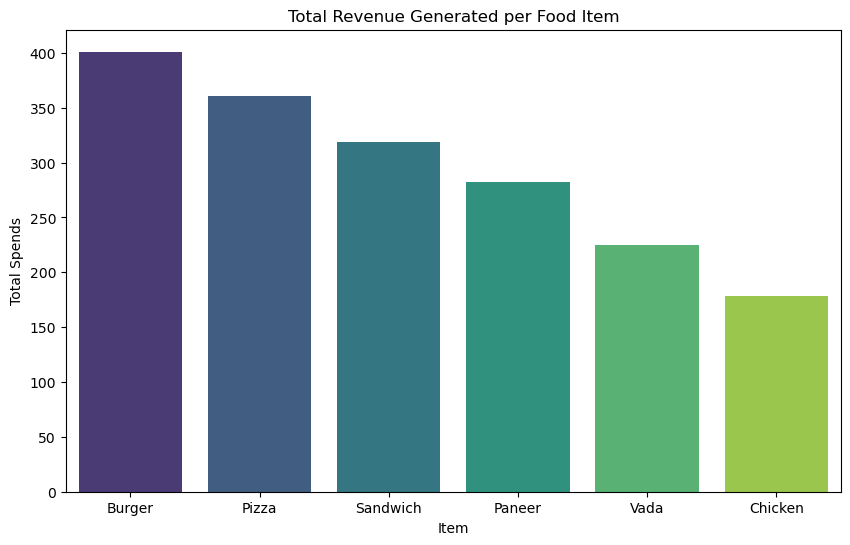

In [35]:
plt.figure(figsize=(10, 6))
# sum of spends per item
item_spending = df.groupby('Item')['Spends'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=item_spending, x='Item', y='Spends', palette='viridis')
plt.title('Total Revenue Generated per Food Item')
plt.ylabel('Total Spends')
plt.show()

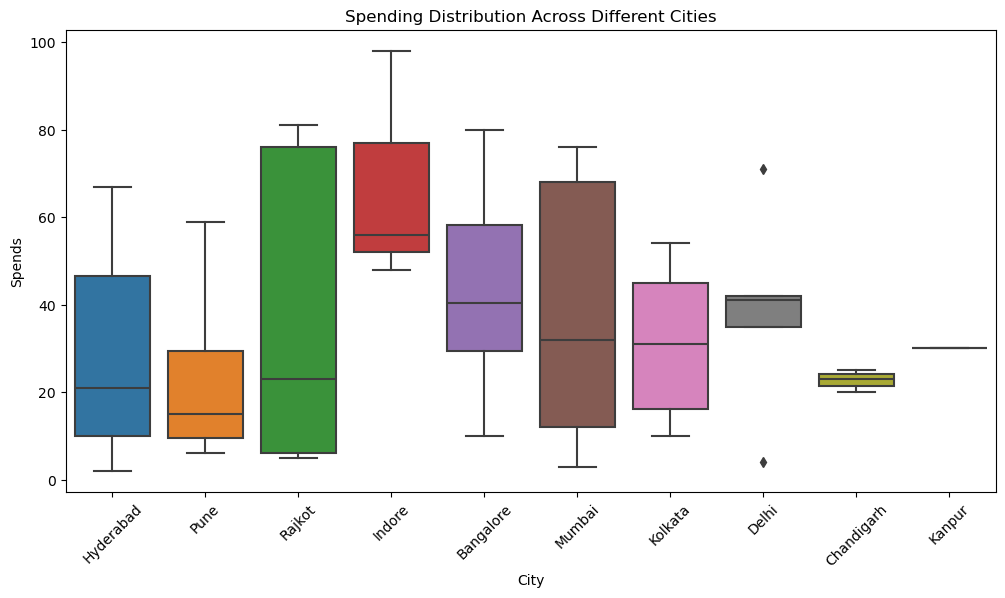

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='City', y='Spends')
plt.title('Spending Distribution Across Different Cities')
plt.xticks(rotation=45)
plt.show()

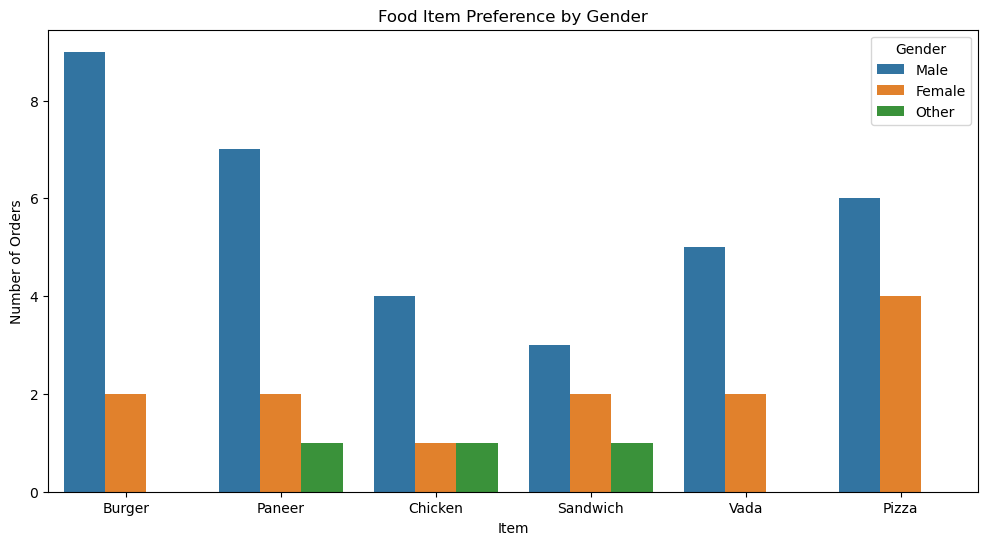

In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Item', hue='Gender')
plt.title('Food Item Preference by Gender')
plt.ylabel('Number of Orders')
plt.show()

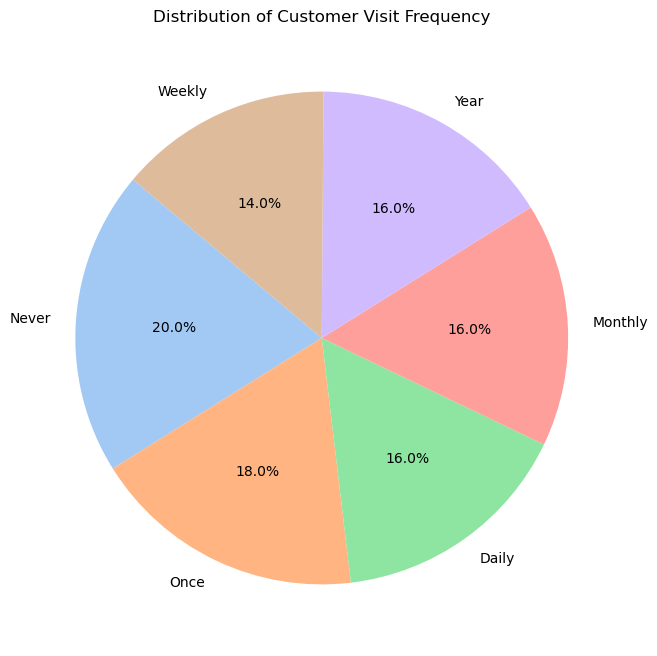

In [32]:
plt.figure(figsize=(8, 8))
frequency_counts = df['Frequency'].value_counts()
plt.pie(frequency_counts, labels=frequency_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Customer Visit Frequency')
plt.show()

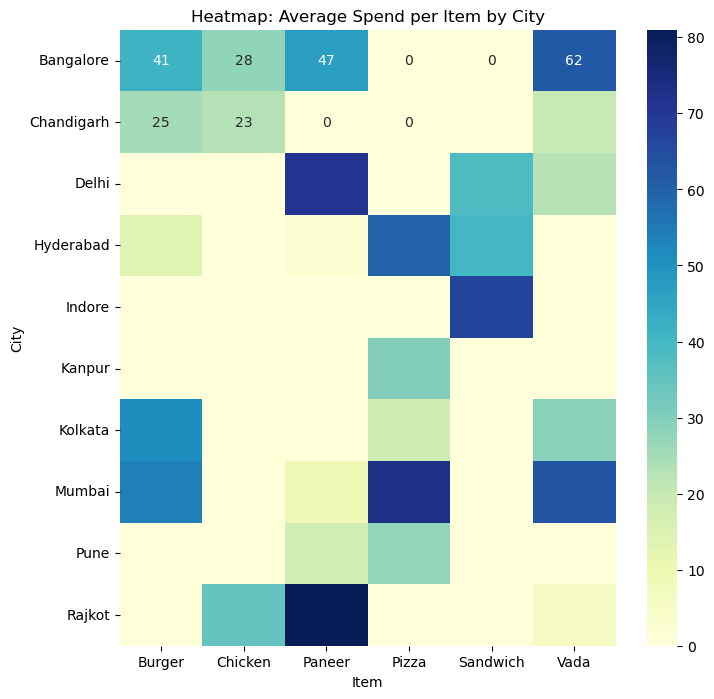

In [31]:
# created a pivot table for the heatmap
pivot_data = wet.pivot_table(index='City', columns='Item', values='Spends', aggfunc='mean')
pivot_data = pivot_data.fillna(0)
plt.figure(figsize=(8, 8))
sns.heatmap(pivot_data, annot=True, cmap='YlGnBu')
plt.title('Heatmap: Average Spend per Item by City')
plt.show()

In [21]:
# Finding orders where spending is above 80 units
high_value_orders = df[df['Spends'] > 80]
print("High Value Orders Segment:\n", high_value_orders.head())
# Finding what 'Daily' customers prefer the most
daily_customers = df[df['Frequency'] == 'Daily']
print("\nTop Items for Daily Customers:\n", daily_customers['Item'].value_counts())

High Value Orders Segment:
               Name Gender    City Frequency      Item  Spends
21  Michael Ashley   Male  Indore     Daily  Sandwich      98
33     Luca Zavala  Other  Rajkot     Never    Paneer      81

Top Items for Daily Customers:
 Item
Paneer      3
Burger      1
Sandwich    1
Chicken     1
Pizza       1
Vada        1
Name: count, dtype: int64


In [22]:
print("Duplicate rows:", df.duplicated().sum())
# Checking for outliers (e.g., spends that are 3x the average)
outliers = df[df['Spends'] > (df['Spends'].mean() * 2.5)]
print("Potential Outliers:\n", outliers)

Duplicate rows: 0
Potential Outliers:
               Name Gender    City Frequency      Item  Spends
21  Michael Ashley   Male  Indore     Daily  Sandwich      98


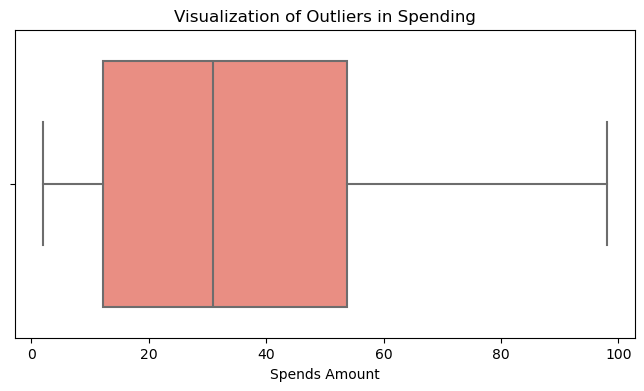

In [23]:
# Created a boxplot to see the outlier visually
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Spends'], color='salmon')
plt.title('Visualization of Outliers in Spending')
plt.xlabel('Spends Amount')
plt.show()

In [24]:
# Identify the threshold (e.g., any spend above 90)
threshold = 90
# Separate the outlier for documentation
outliers = df[df['Spends'] > threshold]
print("Removed Outlier:", outliers)
# Create a 'Cleaned' dataframe without the outlier
df_cleaned = df[df['Spends'] <= threshold]
# Compare the means to see the impact
print(f"Average Spend with Outlier: {df['Spends'].mean():.2f}")
print(f"Average Spend without Outlier: {df_cleaned['Spends'].mean():.2f}")

Removed Outlier:               Name Gender    City Frequency      Item  Spends
21  Michael Ashley   Male  Indore     Daily  Sandwich      98
Average Spend with Outlier: 35.32
Average Spend without Outlier: 34.04


In [25]:
# saving my analyzed/cleaned data permanently
df_cleaned.to_csv('food_analysis_results.csv', index=False)
print("Analysis data saved successfully as CSV!")

Analysis data saved successfully as CSV!
